In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

In [3]:
df=pd.read_csv(r"C:\Users\Sumit's\Downloads\cibil_score.csv")
df = df.drop(columns=["Unnamed: 0"])

In [4]:
df.columns = [col.lower().strip() for col in df.columns]

In [5]:
df.shape

(51336, 87)

In [6]:
int(df.duplicated().sum())

0

In [7]:
df=df.drop_duplicates().reset_index(drop=True)

In [ ]:
df.head().

NameError: name 'df' is not defined

In [9]:
X= df.drop(columns=["approved_flag","credit_score"])

In [10]:
numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

In [11]:
print("NUMERIC_FEATURES:",len(numeric_features))

NUMERIC_FEATURES: 80


In [12]:
categorical_features = X.select_dtypes(
    include=["object","category"]
).columns.tolist()

In [13]:
print("CATEGORICAL_FEATURES:",len(categorical_features))

CATEGORICAL_FEATURES: 5


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        
    ]
)

In [15]:
X_missing_Values = preprocessor.fit_transform(X)

In [16]:
wcss = []
silhouette_scores = []

K_range = range(2, 9)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_missing_Values)

    # WCSS
    wcss.append(kmeans.inertia_)

    # Silhouette
    score = silhouette_score(
        X_missing_Values,
        labels
    )

    silhouette_scores.append(score)

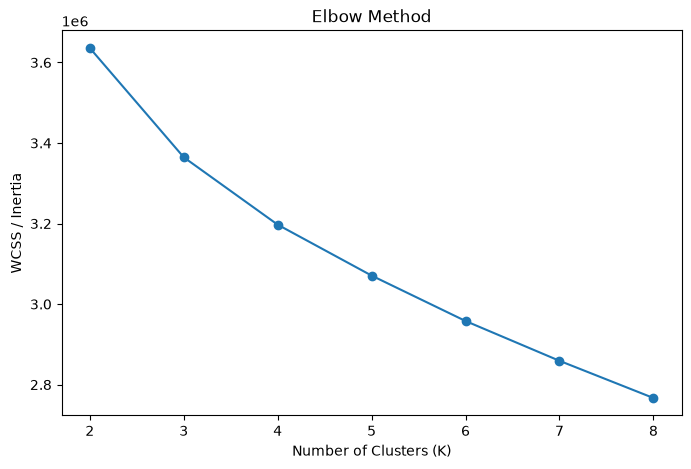

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

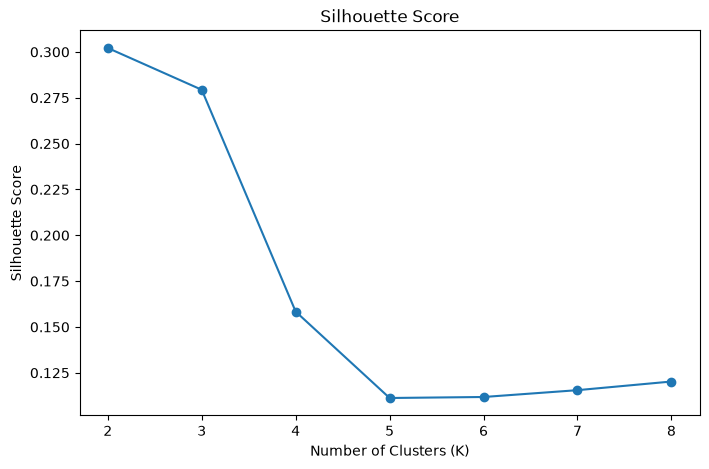

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [19]:
best_k = K_range[
    np.argmax(silhouette_scores)
]
print("Best K according to Silhouette:",
      best_k)
kmeans = KMeans(n_clusters=best_k, n_init=5, random_state=42)
labels = kmeans.fit_predict(X_missing_Values)


Best K according to Silhouette: 2


In [ ]:
print("\nCluster counts:")

unique, counts = np.unique(
    labels,
    return_counts=True
)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count}")


print("\nFinal WCSS:",
      kmeans.inertia_)

print(
    "Final Silhouette Score:",
    silhouette_score(X_missing_Values, labels)
)


Cluster counts:
Cluster 0: 45015
Cluster 1: 6321

Final WCSS: 3635977.512781836
Final Silhouette Score: 0.30213674619819847
